## Importing required libraries

In [182]:
import pandas as pd
import numpy as np
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

## Understanding dataset
 
### Data Dictionary (at first glance)

Results of printing the unique values from each feature. Things I noticed about each feature:

---

#### **Month** - *object*
- Contains 3-letter abbreviations for the months of the year.
- Are these the months in which the accident occurred?

#### **WeekOfMonth** - *int64*
- Provides the week in the month the accident occurred.

#### **DayOfWeek** - *object*
- Contains days of the week.
- Are these the days the accident occurred on?

#### **Make** - *object*
- Contains a list of 19 car manufacturers.

#### **AccidentArea** - *object*
- Classifies accident area as "Urban" or "Rural".

#### **DayOfWeekClaimed** - *object*
- Contains the day of the week the claim was filed.
- Also contains '0' – need to check how many of these exist and consider fixing as missing data.

#### **MonthClaimed** - *object*
- Contains 3-letter abbreviations for the months of the year.
- Contains '0' – need to check how many and what they mean (missing data?).

#### **WeekOfMonthClaimed** - *int64*
- Contains weeks in the month that the claim was filed.

#### **Sex** - *object*
- Gender of the individual making the claim.
- Binary data; convert to 1 or 0.

#### **MaritalStatus** - *object*
- Marital status of the individual making the claim.

#### **Age** - *int64*
- Age of the individual making the claim.
- There is at least one individual with age 0 – possible missing data.

#### **Fault** - *object*
- Categorization of who was deemed at fault.
- Convert to binary: 1 or 0.

#### **PolicyType** - *object*
- Contains two pieces of information:
  - Type of insurance on the car (liability, all perils, collision).
  - Category of the vehicle (sport, sedan, utility).

#### **VehicleCategory** - *object*
- Contains the categorization of the vehicle (see PolicyType).

#### **VehiclePrice** - *object*
- Contains ranges for the value of the vehicle.
- Replace ranges with mean value of the range and convert to float.

#### **FraudFound_P** - *int64*
- Indicates whether the claim was fraudulent (1) or not (0).
- This is the target variable to predict.

#### **PolicyNumber** - *int64*
- The masked policy number; appears to match row number minus 1.

#### **RepNumber** - *int64*
- Representative number (integer from 1 to 16).

#### **Deductible** - *int64*
- The deductible amount (integer values).

#### **DriverRating** - *int64*
- Scale: 1, 2, 3, 4.
- The name suggests ordinal data; is it also interval?

#### **Days_Policy_Accident** - *object*
- Likely the number of days between policy purchase and accident occurrence.
- Values are ranges; replace with mean of range and convert to float.

#### **Days_Policy_Claim** - *object*
- Likely the number of days between policy purchase and claim filing.
- Values are ranges; replace with mean of range and convert to float.

#### **PastNumberOfClaims** - *object*
- Previous number of claims filed by policyholder (or claimant?).

#### **AgeOfVehicle** - *object*
- Represents age of vehicle at time of accident.
- Values are ranges; replace with mean of range and convert to float.

#### **AgeOfPolicyHolder** - *object*
- Values are ranges of ages.
- Replace with mean of range and convert to float.

#### **PoliceReportFiled** - *object*
- Indicates whether a police report was filed for the accident.
- Convert to binary.

#### **WitnessPresent** - *object*
- Indicates whether a witness was present.
- Convert to binary.

#### **AgentType** - *object*
- Classifies agent handling the claim as internal or external.
- What does this mean? Change to binary.

#### **NumberOfSuppliments** - *object*
- Likely not the number of vitamins taken daily.
- Unclear what a supplement is in insurance.

#### **AddressChange_Claim** - *object*
- Guess: time from claim filing to when the person moved (i.e. filed an address change).
- Replace each interval with mean value of range.

#### **NumberOfCars** - *object*
- Guess: number of cars involved in accident OR number of cars covered under policy.
- Replace each interval with mean value of range.

#### **Year** - *int64*
- Likely year accident occurred.

#### **BasePolicy** - *object*
- Type of insurance coverage (see PolicyType).


In [183]:
#Reading the file

df = pd.read_csv("data/Fraud_data.csv", sep = ';')

In [184]:
#First 5 rows of the dataset

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Volkswagen,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,2014,Liability
1,Jan,3,Wednesday,Volkswagen,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,2014,Collision
2,Oct,5,Friday,Volkswagen,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,2014,Collision
3,Jun,2,Saturday,Renault,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,2014,Liability
4,Jan,5,Monday,Volkswagen,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,2014,Collision


In [185]:
#Statistics about the data
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,2014.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,2014.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,2014.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,2015.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,2016.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,2016.000000


In [186]:
#Number of rows and columns in the dataset
df.shape

(15420, 33)

In [187]:
#List of columns in the dataset
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [188]:
#Checking for missing values
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

In [189]:
#More information of the data

df.info()

# Fraud Claim means 1
# Real Claim means 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

This dataset is an own remake for adapt it

In [190]:
#Count of unique values for

df['FraudFound_P'].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [191]:
#Number of unique values in each column

df.nunique()

Month                      12
WeekOfMonth                 5
DayOfWeek                   7
Make                       14
AccidentArea                2
DayOfWeekClaimed            8
MonthClaimed               13
WeekOfMonthClaimed          5
Sex                         2
MaritalStatus               4
Age                        66
Fault                       2
PolicyType                  9
VehicleCategory             3
VehiclePrice                6
FraudFound_P                2
PolicyNumber            15420
RepNumber                  16
Deductible                  4
DriverRating                4
Days_Policy_Accident        5
Days_Policy_Claim           4
PastNumberOfClaims          4
AgeOfVehicle                8
AgeOfPolicyHolder           9
PoliceReportFiled           2
WitnessPresent              2
AgentType                   2
NumberOfSuppliments         4
AddressChange_Claim         5
NumberOfCars                5
Year                        3
BasePolicy                  3
dtype: int

## Analysis

In [192]:
# Gender and marital status of the accident victims (consider with all years)

df_sex_maritalstatus = df.groupby(["Sex", "MaritalStatus"]).agg({"Sex":"count"})
df_sex_maritalstatus.columns = ["Counts"]
df_sex_maritalstatus.reset_index(inplace=True)
print(df_sex_maritalstatus.head(10))


fig = px.bar(df_sex_maritalstatus, x="Sex", y="Counts",
             color='MaritalStatus', barmode='group',
             height=400,
            title = "Gender and marital status of the accident victims")
fig.show()

      Sex MaritalStatus  Counts
0  Female      Divorced      40
1  Female       Married    1325
2  Female        Single    1031
3  Female         Widow      24
4    Male      Divorced      36
5    Male       Married    9300
6    Male        Single    3653
7    Male         Widow      11


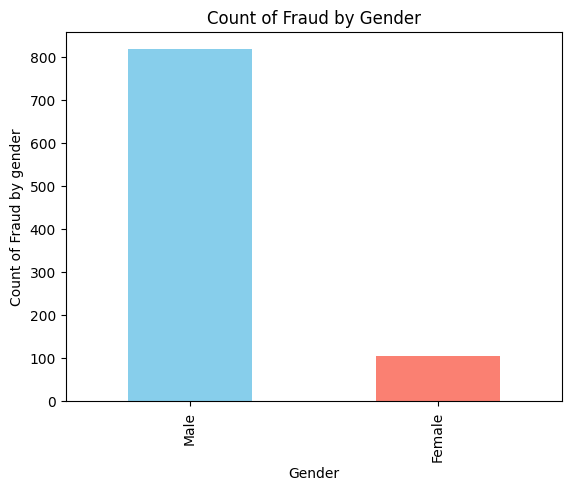

In [193]:
# Count of fraud
frauds_by_sex = df[df['FraudFound_P'] == 1]['Sex'].value_counts()

# Graphing the count of fraud
frauds_by_sex.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Count of Fraud by Gender')
plt.xlabel('Gender')
plt.ylabel('Count of Fraud by gender')
plt.show()


Sex
Male      6.292308
Female    4.338843
Name: count, dtype: float64


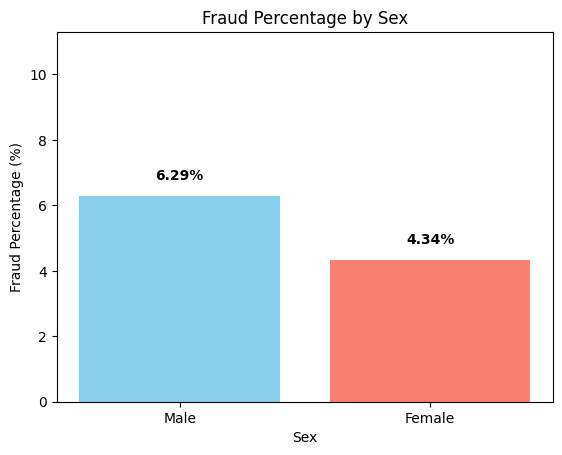

In [194]:
import pandas as pd
import matplotlib.pyplot as plt

# Total number of people by sex
total_by_sex = df['Sex'].value_counts()

# Total frauds by sex
frauds_by_sex = df[df['FraudFound_P'] == 1]['Sex'].value_counts()

# Percentage of fraud within each sex
fraud_percentage = (frauds_by_sex / total_by_sex) * 100

# Print the result
print(fraud_percentage)

# Plot
plt.bar(fraud_percentage.index, fraud_percentage.values, color=['skyblue', 'salmon'])
plt.title('Fraud Percentage by Sex')
plt.xlabel('Sex')
plt.ylabel('Fraud Percentage (%)')

# Add value labels on top of the bars
for i, v in enumerate(fraud_percentage.values):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

plt.ylim(0, fraud_percentage.max() + 5)
plt.show()


In [195]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Agrupación
df_make_vehicle_age = df.groupby(["Make", "AgeOfVehicle"]).agg({"Make":"count"})
df_make_vehicle_age.columns = ["Counts"]
df_make_vehicle_age.reset_index(inplace=True)

# Lista de marcas
brands = ["Mercedes Benz", "Honda", "Ford", "BMW", "Chevrolet", "Fiat", "Toyota", "Volkswagen", "Renault", "Lexus","Ferrari", "Porsche"]

# Subplots: 4 filas x 3 columnas
fig = make_subplots(
    rows=4, cols=3,
    specs=[[{'type':'domain'}]*3]*4
)

# Agregamos los pie charts
for idx, brand in enumerate(brands):
    row = (idx // 3) + 1
    col = (idx % 3) + 1
    brand_data = df_make_vehicle_age[df_make_vehicle_age["Make"] == brand]
    fig.add_trace(
        go.Pie(
            labels=brand_data["AgeOfVehicle"],
            values=brand_data["Counts"],
            name=brand,
            textinfo='percent',
            insidetextorientation='auto'
        ),
        row, col
    )

# Donuts
fig.update_traces(hole=0.4, hoverinfo="label+percent+name")

# Generamos las anotaciones automáticas:
annotations=[dict(text='BMW', x=0.13, y=0.633, font_size=10, showarrow=False),
            dict(text='Chevrolet', x=0.50, y=0.633, font_size=10, showarrow=False),
            dict(text='Fiat', x=0.869, y=0.633, font_size=10, showarrow=False),
            dict(text='Mercedes Benz', x=0.102, y=0.91, font_size=10, showarrow=False),
            dict(text='Honda', x=0.50, y=0.91, font_size=10, showarrow=False),
            dict(text='Ford', x=0.867, y=0.91, font_size=10, showarrow=False),
            dict(text='Toyota', x=0.125, y=0.366, font_size=10, showarrow=False),
            dict(text='Volkswagen', x=0.501, y=0.366, font_size=10, showarrow=False),
            dict(text='Renault', x=0.876, y=0.366, font_size=10, showarrow=False),
            dict(text='Lexus', x=0.125, y=0.09, font_size=10, showarrow=False),
            dict(text='Ferrari', x=0.501, y=0.09, font_size=10, showarrow=False),
            dict(text='Porsche', x=0.876, y=0.09, font_size=10, showarrow=False)]
# Layout
fig.update_layout(
    title_text="Ages of Vehicles Involved in Accidents by Car Brand",
    annotations=annotations,
    width=1200,
    height=1200,
    font=dict(size=14)
)

fig.show()


In [196]:
# Regions where accidents occurred by years
df_area_year = df.groupby(["AccidentArea", "Year"]).agg({"AccidentArea":"count"})
df_area_year.columns = ["Counts"]
df_area_year.reset_index(inplace=True)
print(df_area_year.head(10))


fig = px.bar(df_area_year, x="Year", y="Counts",
             color='AccidentArea', barmode='group',
             height=400,
            title = "Regions where accidents occurred by year")
fig.show()

  AccidentArea  Year  Counts
0        Rural  2014     642
1        Rural  2015     536
2        Rural  2016     420
3        Urban  2014    5500
4        Urban  2015    4659
5        Urban  2016    3663


# EDA

In [197]:
# VehicleCategory + Base Policy we will compare it with Policy Type
# so, we will create a temporary new column as Combined Name which will store combined Value
df['Combined Name'] = ''
df['Combined Name'] = df['VehicleCategory'] +' - ' + df['BasePolicy']

# Creating Policy Relation Column with Base Policy
df['Policy realtion with Base'] = 0
# Matched True 1 for same
# Matched False 0 for different
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Combined Name,Policy realtion with Base
0,Dec,5,Wednesday,Volkswagen,Urban,Tuesday,Jan,1,Female,Single,...,No,No,External,none,1 year,3 to 4,2014,Liability,Sport - Liability,0
1,Jan,3,Wednesday,Volkswagen,Urban,Monday,Jan,4,Male,Single,...,Yes,No,External,none,no change,1 vehicle,2014,Collision,Sport - Collision,0
2,Oct,5,Friday,Volkswagen,Urban,Thursday,Nov,2,Male,Married,...,No,No,External,none,no change,1 vehicle,2014,Collision,Sport - Collision,0
3,Jun,2,Saturday,Renault,Rural,Friday,Jul,1,Male,Married,...,Yes,No,External,more than 5,no change,1 vehicle,2014,Liability,Sport - Liability,0
4,Jan,5,Monday,Volkswagen,Urban,Tuesday,Feb,2,Female,Single,...,No,No,External,none,no change,1 vehicle,2014,Collision,Sport - Collision,0


In [198]:
## if PolicyType and Combined Name Matches then TRUE(same) else on FALSE(diff)

df["Policy realtion with Base"] = (
    df["PolicyType"] == df["Combined Name"]
).map({True: "same", False: "diff"})

In [199]:
# Matched True 1 for same
# Matched False 0 for diff

df['Policy realtion with Base'].replace('same', 1,inplace=True)
df['Policy realtion with Base'].replace('diff', 0,inplace=True)

In [200]:
# As we have got desired results in Policy relation with Base column
# we will remove the temp column

df = df.drop('Combined Name', axis=1)
df = df.drop('PolicyType', axis=1)

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,Dec,5,Wednesday,Volkswagen,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,2014,Liability,1
1,Jan,3,Wednesday,Volkswagen,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,2014,Collision,1
2,Oct,5,Friday,Volkswagen,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,2014,Collision,1
3,Jun,2,Saturday,Renault,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,2014,Liability,0
4,Jan,5,Monday,Volkswagen,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,2014,Collision,1


In [201]:
# Converting Sex, Accident Area and Fault to Intergral Values
# Object Type to int

df = df.assign(
    Sex = (df["Sex"] == "Male").astype(int),
    AccidentArea = (df["AccidentArea"] == "Urban").astype(int),
    Fault = (df["Fault"] == "Policy Holder").astype(int)
)

In [202]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,Dec,5,Wednesday,Volkswagen,1,Tuesday,Jan,1,0,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,2014,Liability,1
1,Jan,3,Wednesday,Volkswagen,1,Monday,Jan,4,1,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,2014,Collision,1
2,Oct,5,Friday,Volkswagen,1,Thursday,Nov,2,1,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,2014,Collision,1
3,Jun,2,Saturday,Renault,0,Friday,Jul,1,1,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,2014,Liability,0
4,Jan,5,Monday,Volkswagen,1,Tuesday,Feb,2,0,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,2014,Collision,1


In [203]:
# Converting Type of column to int which will help us to implement model easily
df['Sex'] = df['Sex'].astype(str).astype(int)
df['Fault'] = df['Fault'].astype(str).astype(int)
df['AccidentArea'] = df['AccidentArea'].astype(str).astype(int)

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Month                      15420 non-null  object
 1   WeekOfMonth                15420 non-null  int64 
 2   DayOfWeek                  15420 non-null  object
 3   Make                       15420 non-null  object
 4   AccidentArea               15420 non-null  int64 
 5   DayOfWeekClaimed           15420 non-null  object
 6   MonthClaimed               15420 non-null  object
 7   WeekOfMonthClaimed         15420 non-null  int64 
 8   Sex                        15420 non-null  int64 
 9   MaritalStatus              15420 non-null  object
 10  Age                        15420 non-null  int64 
 11  Fault                      15420 non-null  int64 
 12  VehicleCategory            15420 non-null  object
 13  VehiclePrice               15420 non-null  object
 14  FraudF

In [205]:
# Fraud has no relation with Policy Number so, we will remove it
df = df.drop('PolicyNumber', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Month                      15420 non-null  object
 1   WeekOfMonth                15420 non-null  int64 
 2   DayOfWeek                  15420 non-null  object
 3   Make                       15420 non-null  object
 4   AccidentArea               15420 non-null  int64 
 5   DayOfWeekClaimed           15420 non-null  object
 6   MonthClaimed               15420 non-null  object
 7   WeekOfMonthClaimed         15420 non-null  int64 
 8   Sex                        15420 non-null  int64 
 9   MaritalStatus              15420 non-null  object
 10  Age                        15420 non-null  int64 
 11  Fault                      15420 non-null  int64 
 12  VehicleCategory            15420 non-null  object
 13  VehiclePrice               15420 non-null  object
 14  FraudF

In [206]:
# Prepare PoliceReportFiled Data for Training the Model for Replacing some unique values
df['PoliceReportFiled'].replace('No', 0,inplace=True)
df['PoliceReportFiled'].replace('Yes', 1,inplace=True)
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,Dec,5,Wednesday,Volkswagen,1,Tuesday,Jan,1,0,Single,...,26 to 30,0,No,External,none,1 year,3 to 4,2014,Liability,1
1,Jan,3,Wednesday,Volkswagen,1,Monday,Jan,4,1,Single,...,31 to 35,1,No,External,none,no change,1 vehicle,2014,Collision,1
2,Oct,5,Friday,Volkswagen,1,Thursday,Nov,2,1,Married,...,41 to 50,0,No,External,none,no change,1 vehicle,2014,Collision,1
3,Jun,2,Saturday,Renault,0,Friday,Jul,1,1,Married,...,51 to 65,1,No,External,more than 5,no change,1 vehicle,2014,Liability,0
4,Jan,5,Monday,Volkswagen,1,Tuesday,Feb,2,0,Single,...,31 to 35,0,No,External,none,no change,1 vehicle,2014,Collision,1


In [207]:
# Prepare WitnessPresent Data for Training the Model for Replacing some unique values
df['WitnessPresent'].replace('No', 0,inplace=True)
df['WitnessPresent'].replace('Yes', 1,inplace=True)
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,Dec,5,Wednesday,Volkswagen,1,Tuesday,Jan,1,0,Single,...,26 to 30,0,0,External,none,1 year,3 to 4,2014,Liability,1
1,Jan,3,Wednesday,Volkswagen,1,Monday,Jan,4,1,Single,...,31 to 35,1,0,External,none,no change,1 vehicle,2014,Collision,1
2,Oct,5,Friday,Volkswagen,1,Thursday,Nov,2,1,Married,...,41 to 50,0,0,External,none,no change,1 vehicle,2014,Collision,1
3,Jun,2,Saturday,Renault,0,Friday,Jul,1,1,Married,...,51 to 65,1,0,External,more than 5,no change,1 vehicle,2014,Liability,0
4,Jan,5,Monday,Volkswagen,1,Tuesday,Feb,2,0,Single,...,31 to 35,0,0,External,none,no change,1 vehicle,2014,Collision,1


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Month                      15420 non-null  object
 1   WeekOfMonth                15420 non-null  int64 
 2   DayOfWeek                  15420 non-null  object
 3   Make                       15420 non-null  object
 4   AccidentArea               15420 non-null  int64 
 5   DayOfWeekClaimed           15420 non-null  object
 6   MonthClaimed               15420 non-null  object
 7   WeekOfMonthClaimed         15420 non-null  int64 
 8   Sex                        15420 non-null  int64 
 9   MaritalStatus              15420 non-null  object
 10  Age                        15420 non-null  int64 
 11  Fault                      15420 non-null  int64 
 12  VehicleCategory            15420 non-null  object
 13  VehiclePrice               15420 non-null  object
 14  FraudF

In [209]:
# Prepare Agent Type Data for Training the Model for Replacing some unique values
df['AgentType'].replace('External', 0,inplace=True)
df['AgentType'].replace('Internal', 1,inplace=True)
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,Dec,5,Wednesday,Volkswagen,1,Tuesday,Jan,1,0,Single,...,26 to 30,0,0,0,none,1 year,3 to 4,2014,Liability,1
1,Jan,3,Wednesday,Volkswagen,1,Monday,Jan,4,1,Single,...,31 to 35,1,0,0,none,no change,1 vehicle,2014,Collision,1
2,Oct,5,Friday,Volkswagen,1,Thursday,Nov,2,1,Married,...,41 to 50,0,0,0,none,no change,1 vehicle,2014,Collision,1
3,Jun,2,Saturday,Renault,0,Friday,Jul,1,1,Married,...,51 to 65,1,0,0,more than 5,no change,1 vehicle,2014,Liability,0
4,Jan,5,Monday,Volkswagen,1,Tuesday,Feb,2,0,Single,...,31 to 35,0,0,0,none,no change,1 vehicle,2014,Collision,1


In [210]:
df['Make'].value_counts()


Make
Fiat             3843
Renault          3593
Ford             2913
Volkswagen       2884
Chevrolet        1681
Toyota            283
Peugeot           108
Honda              58
Nissan             30
BMW                15
Porsche             5
Mercedes Benz       4
Ferrari             2
Lexus               1
Name: count, dtype: int64

In [211]:
# Preparing Make Column to some Denoting values
df['Make'].replace('Fiat', 0,inplace=True)
df['Make'].replace('Renault', 1,inplace=True)
df['Make'].replace('Ford', 2,inplace=True)
df['Make'].replace('Volkswagen', 3,inplace=True)
df['Make'].replace('Chevrolet', 4,inplace=True)
df['Make'].replace('Toyota', 5,inplace=True)
df['Make'].replace('Peugeot', 6,inplace=True)
df['Make'].replace('Honda', 7,inplace=True)
df['Make'].replace('Nissan', 8,inplace=True)
df['Make'].replace('BMW', 9,inplace=True)
df['Make'].replace('Porsche', 10,inplace=True)
df['Make'].replace('Mercedes Benz', 11,inplace=True)
df['Make'].replace('Ferrari', 12,inplace=True)
df['Make'].replace('Lexus', 13,inplace=True)

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,Dec,5,Wednesday,3,1,Tuesday,Jan,1,0,Single,...,26 to 30,0,0,0,none,1 year,3 to 4,2014,Liability,1
1,Jan,3,Wednesday,3,1,Monday,Jan,4,1,Single,...,31 to 35,1,0,0,none,no change,1 vehicle,2014,Collision,1
2,Oct,5,Friday,3,1,Thursday,Nov,2,1,Married,...,41 to 50,0,0,0,none,no change,1 vehicle,2014,Collision,1
3,Jun,2,Saturday,1,0,Friday,Jul,1,1,Married,...,51 to 65,1,0,0,more than 5,no change,1 vehicle,2014,Liability,0
4,Jan,5,Monday,3,1,Tuesday,Feb,2,0,Single,...,31 to 35,0,0,0,none,no change,1 vehicle,2014,Collision,1


In [212]:
# Prepare VehicelCategoruy Data for Training the Model for Replacing some unique values
df['VehicleCategory'].replace('Sport', 0,inplace=True)
df['VehicleCategory'].replace('Sedan', 1,inplace=True)
df['VehicleCategory'].replace('Utility', 2,inplace=True)

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,Dec,5,Wednesday,3,1,Tuesday,Jan,1,0,Single,...,26 to 30,0,0,0,none,1 year,3 to 4,2014,Liability,1
1,Jan,3,Wednesday,3,1,Monday,Jan,4,1,Single,...,31 to 35,1,0,0,none,no change,1 vehicle,2014,Collision,1
2,Oct,5,Friday,3,1,Thursday,Nov,2,1,Married,...,41 to 50,0,0,0,none,no change,1 vehicle,2014,Collision,1
3,Jun,2,Saturday,1,0,Friday,Jul,1,1,Married,...,51 to 65,1,0,0,more than 5,no change,1 vehicle,2014,Liability,0
4,Jan,5,Monday,3,1,Tuesday,Feb,2,0,Single,...,31 to 35,0,0,0,none,no change,1 vehicle,2014,Collision,1


In [213]:
df['MaritalStatus'].unique()

array(['Single', 'Married', 'Widow', 'Divorced'], dtype=object)

In [214]:
df['MaritalStatus'].replace('Widow', 0,inplace=True)
df['MaritalStatus'].replace('Single', 1,inplace=True)
df['MaritalStatus'].replace('Married', 2,inplace=True)
df['MaritalStatus'].replace('Divorced', 3,inplace=True)

In [215]:
df['NumberOfSuppliments'].replace('none', 0,inplace=True)
df['NumberOfSuppliments'].replace('1 to 2', 1.5,inplace=True)
df['NumberOfSuppliments'].replace('3 to 5', 4,inplace=True)
df['NumberOfSuppliments'].replace('more than 5', 6,inplace=True)

In [216]:
df['BasePolicy'].replace('Liability', 0,inplace=True)
df['BasePolicy'].replace('Collision', 1,inplace=True)
df['BasePolicy'].replace('All Perils', 2,inplace=True)

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      15420 non-null  object 
 1   WeekOfMonth                15420 non-null  int64  
 2   DayOfWeek                  15420 non-null  object 
 3   Make                       15420 non-null  int64  
 4   AccidentArea               15420 non-null  int64  
 5   DayOfWeekClaimed           15420 non-null  object 
 6   MonthClaimed               15420 non-null  object 
 7   WeekOfMonthClaimed         15420 non-null  int64  
 8   Sex                        15420 non-null  int64  
 9   MaritalStatus              15420 non-null  int64  
 10  Age                        15420 non-null  int64  
 11  Fault                      15420 non-null  int64  
 12  VehicleCategory            15420 non-null  int64  
 13  VehiclePrice               15420 non-null  obj

### Still 15 Objects Remaining

In [218]:
# Converting DayofWeek to some meaningful value
df['DayOfWeek'].replace('Sunday', 0,inplace=True)
df['DayOfWeek'].replace('Monday', 1,inplace=True)
df['DayOfWeek'].replace('Tuesday', 2,inplace=True)
df['DayOfWeek'].replace('Wednesday', 3,inplace=True)
df['DayOfWeek'].replace('Thursday', 4,inplace=True)
df['DayOfWeek'].replace('Friday', 5,inplace=True)
df['DayOfWeek'].replace('Saturday', 6,inplace=True)

In [219]:
df['DayOfWeekClaimed'].replace('Sunday', 0,inplace=True)
df['DayOfWeekClaimed'].replace('Monday', 1,inplace=True)
df['DayOfWeekClaimed'].replace('Tuesday', 2,inplace=True)
df['DayOfWeekClaimed'].replace('Wednesday', 3,inplace=True)
df['DayOfWeekClaimed'].replace('Thursday', 4,inplace=True)
df['DayOfWeekClaimed'].replace('Friday', 5,inplace=True)
df['DayOfWeekClaimed'].replace('Saturday', 6,inplace=True)

In [220]:
df['DayOfWeekClaimed'].unique()

array([2, 1, 4, 5, 3, 6, 0, '0'], dtype=object)

In [221]:
# Converting Month to some meaningful value
df['Month'].replace('Jan', 1,inplace=True)
df['Month'].replace('Feb', 2,inplace=True)
df['Month'].replace('Mar', 3,inplace=True)
df['Month'].replace('Apr', 4,inplace=True)
df['Month'].replace('May', 5,inplace=True)
df['Month'].replace('Jun', 6,inplace=True)
df['Month'].replace('Jul', 7,inplace=True)
df['Month'].replace('Aug', 8,inplace=True)
df['Month'].replace('Sep', 9,inplace=True)
df['Month'].replace('Oct', 10,inplace=True)
df['Month'].replace('Nov', 11,inplace=True)
df['Month'].replace('Dec', 12,inplace=True)

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,12,5,3,3,1,2,Jan,1,0,1,...,26 to 30,0,0,0,0.0,1 year,3 to 4,2014,0,1
1,1,3,3,3,1,1,Jan,4,1,1,...,31 to 35,1,0,0,0.0,no change,1 vehicle,2014,1,1
2,10,5,5,3,1,4,Nov,2,1,2,...,41 to 50,0,0,0,0.0,no change,1 vehicle,2014,1,1
3,6,2,6,1,0,5,Jul,1,1,2,...,51 to 65,1,0,0,6.0,no change,1 vehicle,2014,0,0
4,1,5,1,3,1,2,Feb,2,0,1,...,31 to 35,0,0,0,0.0,no change,1 vehicle,2014,1,1


In [222]:
df['Month'].unique()

array([12,  1, 10,  6,  2, 11,  4,  3,  8,  7,  5,  9])

In [223]:
# Converting MonthClaimed to some meaningful value
df['MonthClaimed'].replace('Jan', 1,inplace=True)
df['MonthClaimed'].replace('Feb', 2,inplace=True)
df['MonthClaimed'].replace('Mar', 3,inplace=True)
df['MonthClaimed'].replace('Apr', 4,inplace=True)
df['MonthClaimed'].replace('May', 5,inplace=True)
df['MonthClaimed'].replace('Jun', 6,inplace=True)
df['MonthClaimed'].replace('Jul', 7,inplace=True)
df['MonthClaimed'].replace('Aug', 8,inplace=True)
df['MonthClaimed'].replace('Sep', 9,inplace=True)
df['MonthClaimed'].replace('Oct', 10,inplace=True)
df['MonthClaimed'].replace('Nov', 11,inplace=True)
df['MonthClaimed'].replace('Dec', 12,inplace=True)

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,12,5,3,3,1,2,1,1,0,1,...,26 to 30,0,0,0,0.0,1 year,3 to 4,2014,0,1
1,1,3,3,3,1,1,1,4,1,1,...,31 to 35,1,0,0,0.0,no change,1 vehicle,2014,1,1
2,10,5,5,3,1,4,11,2,1,2,...,41 to 50,0,0,0,0.0,no change,1 vehicle,2014,1,1
3,6,2,6,1,0,5,7,1,1,2,...,51 to 65,1,0,0,6.0,no change,1 vehicle,2014,0,0
4,1,5,1,3,1,2,2,2,0,1,...,31 to 35,0,0,0,0.0,no change,1 vehicle,2014,1,1


In [224]:
# Grouping AgeofPolicyHolder to some meaningful value
df['AgeOfPolicyHolder'].unique()

array(['26 to 30', '31 to 35', '41 to 50', '51 to 65', '21 to 25',
       '36 to 40', '16 to 17', 'over 65', '18 to 20'], dtype=object)

In [225]:
df['AgeOfPolicyHolder'].replace('16 to 17', 16.5,inplace=True)
df['AgeOfPolicyHolder'].replace('18 to 20', 19,inplace=True)
df['AgeOfPolicyHolder'].replace('21 to 25', 23,inplace=True)
df['AgeOfPolicyHolder'].replace('26 to 30', 28,inplace=True)
df['AgeOfPolicyHolder'].replace('31 to 35', 33,inplace=True)
df['AgeOfPolicyHolder'].replace('36 to 40', 38,inplace=True)
df['AgeOfPolicyHolder'].replace('41 to 50', 45.5,inplace=True)
df['AgeOfPolicyHolder'].replace('51 to 65', 58,inplace=True)
df['AgeOfPolicyHolder'].replace('over 65', 69,inplace=True)

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,12,5,3,3,1,2,1,1,0,1,...,28.0,0,0,0,0.0,1 year,3 to 4,2014,0,1
1,1,3,3,3,1,1,1,4,1,1,...,33.0,1,0,0,0.0,no change,1 vehicle,2014,1,1
2,10,5,5,3,1,4,11,2,1,2,...,45.5,0,0,0,0.0,no change,1 vehicle,2014,1,1
3,6,2,6,1,0,5,7,1,1,2,...,58.0,1,0,0,6.0,no change,1 vehicle,2014,0,0
4,1,5,1,3,1,2,2,2,0,1,...,33.0,0,0,0,0.0,no change,1 vehicle,2014,1,1


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      15420 non-null  int64  
 1   WeekOfMonth                15420 non-null  int64  
 2   DayOfWeek                  15420 non-null  int64  
 3   Make                       15420 non-null  int64  
 4   AccidentArea               15420 non-null  int64  
 5   DayOfWeekClaimed           15420 non-null  object 
 6   MonthClaimed               15420 non-null  object 
 7   WeekOfMonthClaimed         15420 non-null  int64  
 8   Sex                        15420 non-null  int64  
 9   MaritalStatus              15420 non-null  int64  
 10  Age                        15420 non-null  int64  
 11  Fault                      15420 non-null  int64  
 12  VehicleCategory            15420 non-null  int64  
 13  VehiclePrice               15420 non-null  obj

In [227]:
df['NumberOfCars'].unique()

array(['3 to 4', '1 vehicle', '2 vehicles', '5 to 8', 'more than 8'],
      dtype=object)

In [228]:
# Prepare NumberOfCars Data for Training the Model for Replacing some unique values
df['NumberOfCars'].replace('1 vehicle', 1,inplace=True)
df['NumberOfCars'].replace('3 to 4', 3.5,inplace=True)
df['NumberOfCars'].replace('5 to 8', 6.5,inplace=True)
df['NumberOfCars'].replace('2 vehicles', 2,inplace=True)
df['NumberOfCars'].replace('more than 8', 10,inplace=True)

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,12,5,3,3,1,2,1,1,0,1,...,28.0,0,0,0,0.0,1 year,3.5,2014,0,1
1,1,3,3,3,1,1,1,4,1,1,...,33.0,1,0,0,0.0,no change,1.0,2014,1,1
2,10,5,5,3,1,4,11,2,1,2,...,45.5,0,0,0,0.0,no change,1.0,2014,1,1
3,6,2,6,1,0,5,7,1,1,2,...,58.0,1,0,0,6.0,no change,1.0,2014,0,0
4,1,5,1,3,1,2,2,2,0,1,...,33.0,0,0,0,0.0,no change,1.0,2014,1,1


In [229]:
df['AddressChange_Claim'].unique()

array(['1 year', 'no change', '4 to 8 years', '2 to 3 years',
       'under 6 months'], dtype=object)

In [230]:
# Grouping AddressChange_Claim to meaning ful Values by taking Average of Range

df['AddressChange_Claim'].replace('1 year', 1,inplace=True)
df['AddressChange_Claim'].replace('no change', 0,inplace=True)
df['AddressChange_Claim'].replace('4 to 8 years', 6,inplace=True)
df['AddressChange_Claim'].replace('2 to 3 years', 2.5,inplace=True)
df['AddressChange_Claim'].replace('under 6 months', 0.3,inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      15420 non-null  int64  
 1   WeekOfMonth                15420 non-null  int64  
 2   DayOfWeek                  15420 non-null  int64  
 3   Make                       15420 non-null  int64  
 4   AccidentArea               15420 non-null  int64  
 5   DayOfWeekClaimed           15420 non-null  object 
 6   MonthClaimed               15420 non-null  object 
 7   WeekOfMonthClaimed         15420 non-null  int64  
 8   Sex                        15420 non-null  int64  
 9   MaritalStatus              15420 non-null  int64  
 10  Age                        15420 non-null  int64  
 11  Fault                      15420 non-null  int64  
 12  VehicleCategory            15420 non-null  int64  
 13  VehiclePrice               15420 non-null  obj

In [231]:
# Grouping PastNumberOfClaims to meaning ful Values by taking Average of Range
df['PastNumberOfClaims'].replace('none', 0,inplace=True)
df['PastNumberOfClaims'].replace('1', 1,inplace=True)
df['PastNumberOfClaims'].replace('2 to 4', 3,inplace=True)
df['PastNumberOfClaims'].replace('more than 4', 7,inplace=True)

In [232]:
df['AgeOfVehicle'].unique()

array(['3 years', '6 years', '7 years', 'more than 7', '5 years', 'new',
       '4 years', '2 years'], dtype=object)

In [233]:
# Grouping AgeOfVehicle to meaning ful Values by taking Average of Range
df['AgeOfVehicle'].replace('3 years', 3,inplace=True)
df['AgeOfVehicle'].replace('6 years', 6,inplace=True)
df['AgeOfVehicle'].replace('7 years', 7,inplace=True)
df['AgeOfVehicle'].replace('5 years', 5,inplace=True)
df['AgeOfVehicle'].replace('new', 0,inplace=True)
df['AgeOfVehicle'].replace('more than 7', 10,inplace=True)
df['AgeOfVehicle'].replace('4 years', 4,inplace=True)
df['AgeOfVehicle'].replace('2 years', 2,inplace=True)

In [234]:
df['Days_Policy_Claim'].unique()

array(['more than 30', '15 to 30', '8 to 15', 'none'], dtype=object)

In [235]:
df['Days_Policy_Claim'].replace('none', 0,inplace=True)
df['Days_Policy_Claim'].replace('8 to 15', 11.5,inplace=True)
df['Days_Policy_Claim'].replace('15 to 30', 22.5,inplace=True)
df['Days_Policy_Claim'].replace('more than 30', 38,inplace=True)
df['Days_Policy_Accident'].unique()

array(['more than 30', '15 to 30', 'none', '1 to 7', '8 to 15'],
      dtype=object)

In [236]:
df['Days_Policy_Accident'].replace('1 to 7', 4,inplace=True)
df['Days_Policy_Accident'].replace('8 to 15', 11.5,inplace=True)
df['Days_Policy_Accident'].replace('15 to 30', 22.5,inplace=True)
df['Days_Policy_Accident'].replace('more than 30', 38,inplace=True)
df['Days_Policy_Accident'].replace('none', 0,inplace=True)

df['VehiclePrice'].unique()

array(['more than 69000', '20000 to 29000', '30000 to 39000',
       'less than 20000', '40000 to 59000', '60000 to 69000'],
      dtype=object)

In [237]:
# Grouping VehiclePrice to meaning ful Values by taking Average of Range
df['VehiclePrice'].replace('less than 20000', 15000,inplace=True)
df['VehiclePrice'].replace('20000 to 29000', 24500,inplace=True)
df['VehiclePrice'].replace('30000 to 39000', 34500,inplace=True)
df['VehiclePrice'].replace('40000 to 59000', 44500,inplace=True)
df['VehiclePrice'].replace('60000 to 69000', 64500,inplace=True)
df['VehiclePrice'].replace('more than 69000', 74500,inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      15420 non-null  int64  
 1   WeekOfMonth                15420 non-null  int64  
 2   DayOfWeek                  15420 non-null  int64  
 3   Make                       15420 non-null  int64  
 4   AccidentArea               15420 non-null  int64  
 5   DayOfWeekClaimed           15420 non-null  object 
 6   MonthClaimed               15420 non-null  object 
 7   WeekOfMonthClaimed         15420 non-null  int64  
 8   Sex                        15420 non-null  int64  
 9   MaritalStatus              15420 non-null  int64  
 10  Age                        15420 non-null  int64  
 11  Fault                      15420 non-null  int64  
 12  VehicleCategory            15420 non-null  int64  
 13  VehiclePrice               15420 non-null  int

In [238]:
df['MonthClaimed'].unique()

array([1, 11, 7, 2, 3, 12, 4, 8, 5, 6, 9, 10, '0'], dtype=object)

In [239]:
# Converting DataType to int for fittig Model properly
df['MonthClaimed'] = df['MonthClaimed'].astype(int)
df['DayOfWeekClaimed'] = df['DayOfWeekClaimed'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      15420 non-null  int64  
 1   WeekOfMonth                15420 non-null  int64  
 2   DayOfWeek                  15420 non-null  int64  
 3   Make                       15420 non-null  int64  
 4   AccidentArea               15420 non-null  int64  
 5   DayOfWeekClaimed           15420 non-null  int64  
 6   MonthClaimed               15420 non-null  int64  
 7   WeekOfMonthClaimed         15420 non-null  int64  
 8   Sex                        15420 non-null  int64  
 9   MaritalStatus              15420 non-null  int64  
 10  Age                        15420 non-null  int64  
 11  Fault                      15420 non-null  int64  
 12  VehicleCategory            15420 non-null  int64  
 13  VehiclePrice               15420 non-null  int

In [240]:
df.describe()
## All Data Prepared for applying Model

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,...,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,6.391699,2.788586,3.015694,1.800908,0.896368,2.804604,6.355318,2.693969,0.843061,1.696628,...,39.421401,0.027756,0.005642,0.015629,2.270006,0.303807,1.114948,2014.866472,0.963684,0.676589
std,3.473022,1.287585,1.943762,1.537874,0.304792,1.442462,3.465433,1.259115,0.363755,0.475131,...,10.031628,0.164279,0.074904,0.124039,2.516256,1.228799,0.485038,0.803313,0.782355,0.467793
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,16.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2014.000000,0.000000,0.000000
25%,3.000000,2.000000,1.000000,1.000000,1.000000,2.000000,3.000000,2.000000,1.000000,1.000000,...,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2014.000000,0.000000,0.000000
50%,6.000000,3.000000,3.000000,2.000000,1.000000,3.000000,6.000000,3.000000,1.000000,2.000000,...,38.000000,0.000000,0.000000,0.000000,1.500000,0.000000,1.000000,2015.000000,1.000000,1.000000
75%,9.000000,4.000000,5.000000,3.000000,1.000000,4.000000,9.000000,4.000000,1.000000,2.000000,...,45.500000,0.000000,0.000000,0.000000,6.000000,0.000000,1.000000,2016.000000,2.000000,1.000000
max,12.000000,5.000000,6.000000,13.000000,1.000000,6.000000,12.000000,5.000000,1.000000,3.000000,...,69.000000,1.000000,1.000000,1.000000,6.000000,6.000000,10.000000,2016.000000,2.000000,1.000000


# Building Model

In [241]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Policy realtion with Base
0,12,5,3,3,1,2,1,1,0,1,...,28.0,0,0,0,0.0,1.0,3.5,2014,0,1
1,1,3,3,3,1,1,1,4,1,1,...,33.0,1,0,0,0.0,0.0,1.0,2014,1,1
2,10,5,5,3,1,4,11,2,1,2,...,45.5,0,0,0,0.0,0.0,1.0,2014,1,1
3,6,2,6,1,0,5,7,1,1,2,...,58.0,1,0,0,6.0,0.0,1.0,2014,0,0
4,1,5,1,3,1,2,2,2,0,1,...,33.0,0,0,0,0.0,0.0,1.0,2014,1,1


### Splitting the dataset

In [242]:
X = df.drop(['FraudFound_P'], axis = 1)
y = df['FraudFound_P']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [243]:
#List for model names and their respective accuracy score
models = []
scores = []

from sklearn.metrics import accuracy_score

# Implementing Models

## Support Vector Classifier

In [244]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)
svc_score = accuracy_score(y_test, svc_pred)
svc_score

0.940337224383917

In [245]:
models.append('Support Vector')
scores.append(svc_score)

## Naive Bayes

In [246]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_score = accuracy_score(y_test, nb_pred)

nb_score

0.9092088197146563

In [247]:
models.append('Naive Bayes')
scores.append(nb_score)

## K Nearest Neighbours Classifier

Text(0, 0.5, 'Error')

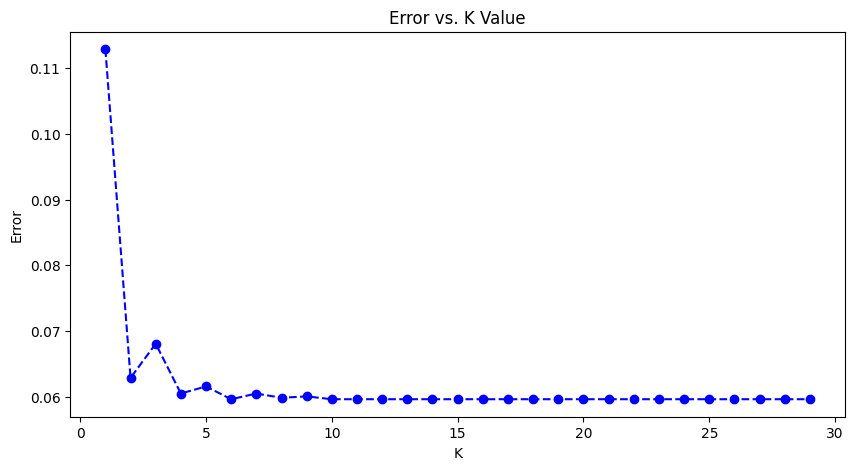

In [248]:
from sklearn.neighbors import KNeighborsClassifier

error_knn = []
for i in range(1, 30):
 knn = KNeighborsClassifier(n_neighbors = i)
 knn.fit(X_train, y_train)
 pred_i = knn.predict(X_test)
 error_knn.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 30), error_knn, color = 'blue', linestyle = 'dashed', marker = 'o')
plt.title('Error vs. K Value')
plt.xlabel('K')
plt.ylabel('Error')

In [249]:
k = error_knn.index(min(error_knn)) + 1
k

6

In [250]:
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(X_train,y_train)
knn_pred = knn.predict(X_test)
knn_score = accuracy_score(y_test, knn_pred)
knn_score

0.940337224383917

In [251]:
models.append('K Nearest Neighbours')
scores.append(knn_score)

## Decision Tree Classifier

In [252]:
from sklearn.tree import DecisionTreeClassifier

max_accuracy = 0
#selecting random state providing the highest accuracy
for x in range(200):
    dtc = DecisionTreeClassifier(random_state=x)
    dtc.fit(X_train,y_train)
    dtc_pred = dtc.predict(X_test)
    current_accuracy = round(accuracy_score(dtc_pred,y_test)*100,2)
    if(current_accuracy > max_accuracy):
        max_accuracy = current_accuracy
        best_x = x

In [253]:
dtc = DecisionTreeClassifier(random_state = best_x)
dtc.fit(X_train,y_train)
dtc_pred = dtc.predict(X_test)
dtc_score = accuracy_score(y_test, dtc_pred)

In [254]:
dtc_score

0.8981841763942932

In [255]:
models.append('Decision Tree')
scores.append(dtc_score)

## Random Forest Classifier

In [256]:
from sklearn.ensemble import RandomForestClassifier

max_accuracy = 0
#selecting random state providing the highest accuracy
for x in range(10):
    rfc = RandomForestClassifier(random_state = x)
    rfc.fit(X_train,y_train)
    rfc_pred = rfc.predict(X_test)
    current_accuracy = round(accuracy_score(y_test, rfc_pred)*100,2)
    if(current_accuracy > max_accuracy):
        max_accuracy = current_accuracy
        rfc_best_x = x

In [257]:
rfc = RandomForestClassifier(random_state = rfc_best_x)
rfc.fit(X_train,y_train)
rfc_pred = rfc.predict(X_test)
rfc_score = accuracy_score(y_test, rfc_pred)

In [258]:
rfc_score

0.9414180717682663

In [259]:
models.append('Random Forest')
scores.append(rfc_score)

## XGBoost Classifier

In [260]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)
xgb_score = accuracy_score(y_test, xgb_pred)

In [261]:
xgb_score

0.9383916990920882

In [262]:
models.append('XGBoost')
scores.append(xgb_score)

### Logistic Regression

In [263]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_score = accuracy_score(y_test, lr_pred)
lr_score

0.940337224383917

In [264]:
models.append('Logistic Regression')
scores.append(lr_score)

### All Models for selecting Best Model

In [265]:
models

['Support Vector',
 'Naive Bayes',
 'K Nearest Neighbours',
 'Decision Tree',
 'Random Forest',
 'XGBoost',
 'Logistic Regression']

In [266]:
scores

[0.940337224383917,
 0.9092088197146563,
 0.940337224383917,
 0.8981841763942932,
 0.9414180717682663,
 0.9383916990920882,
 0.940337224383917]

# Results

In [267]:
percentage_scores = [score*100 for score in scores]

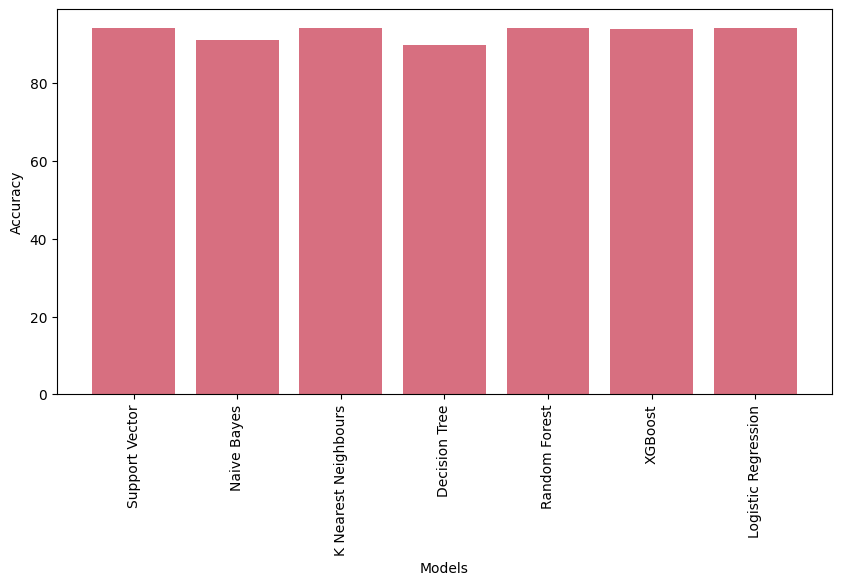

In [268]:
plt.figure(figsize=(10,5))
heartred = '#D76F80'
plt.bar(models, percentage_scores, color = heartred)
plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.xticks(rotation = 90)
plt.show()

In [269]:
results = pd.DataFrame(list(zip(models, percentage_scores)), columns =['Models', 'Accuracy (%)'])

In [180]:
results

,Models,Accuracy (%)
0,Support Vector,94.033722
1,Naive Bayes,90.920882
2,K Nearest Neighbours,94.033722
3,Decision Tree,89.818418
4,Random Forest,94.141807
5,XGBoost,93.839170
6,Logistic Regression,94.033722


Random Forest Regression shows higgest accuracy

In [181]:
!jupyter nbconvert --to html fraud_detection.ipynb

[NbConvertApp] Converting notebook fraud_detection.ipynb to html
/Library/Frameworks/Python.framework/Versions/3.11/share/jupyter/nbconvert/templates/base/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.plotly.v1+json']) is not able to be represented.
  {%- elif type == 'text/vnd.mermaid' -%}
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 15248752 bytes to fraud_detection.html
